# Model Klasifikasi Aksara Jawa dengan ResNet50


In [24]:
# =========================
# IMPORT LIBRARY
# =========================
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.13.1


# KONFIGURASI DATASET


In [ ]:
DATASET_DIR = Path("Dataset")   # folder dataset utama
IMG_SIZE = 224                  # ukuran input standar ResNet50
BATCH_SIZE = 32
SEED = 42
EPOCHS = 25

VALID_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".webp")

In [ ]:
image_paths = []
labels = []

class_folders = sorted([p for p in DATASET_DIR.iterdir() if p.is_dir()])

if len(class_folders) == 0:
    raise ValueError("Tidak ada subfolder kelas di dalam folder dataset.")

for class_folder in class_folders:
    class_name = class_folder.name
    for file_path in class_folder.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in VALID_EXT:
            image_paths.append(str(file_path))
            labels.append(class_name)

image_paths = np.array(image_paths)
labels = np.array(labels)
class_names = sorted(np.unique(labels))
class_to_index = {name: idx for idx, name in enumerate(class_names)}
y = np.array([class_to_index[label] for label in labels])

print("Total gambar  :", len(image_paths))
print("Jumlah kelas  :", len(class_names))
print("Nama kelas    :", class_names)

if len(image_paths) == 0:
    raise ValueError("Tidak ada file gambar yang ditemukan di dalam folder dataset.")

Total gambar  : 10000
Jumlah kelas  : 20
Nama kelas    : ['ba', 'ca', 'da', 'dha', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'tha', 'wa', 'ya']


# DISTRIBUSI DATA PER KELAS

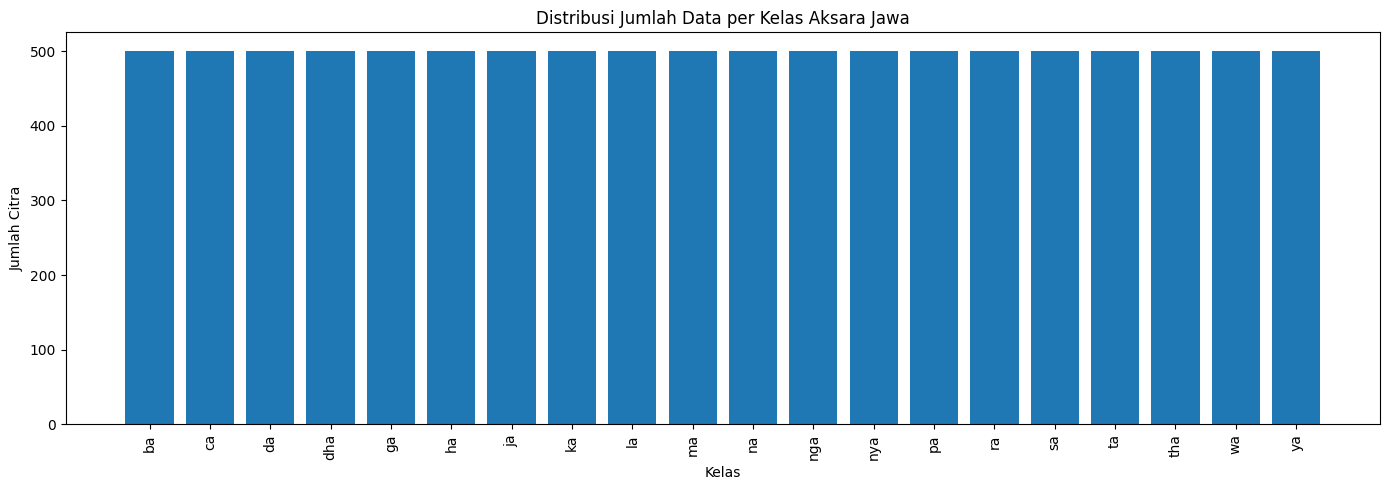

In [ ]:
# =========================
label_counts = Counter(labels)

plt.figure(figsize=(14, 5))
plt.bar(label_counts.keys(), label_counts.values())
plt.title("Distribusi Jumlah Data per Kelas Aksara Jawa")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Citra")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# SPLIT DATA: TRAIN, VALIDATION, TEST

In [ ]:
# 70% train, 15% validation, 15% test

X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Data train     :", len(X_train))
print("Data validation:", len(X_val))
print("Data test      :", len(X_test))

Data train     : 7000
Data validation: 1500
Data test      : 1500


# PREPROCESSING GAMBAR

In [ ]:
def load_and_preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)  # preprocessing khusus ResNet50
    return img, label


def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds = make_dataset(X_val, y_val)
test_ds = make_dataset(X_test, y_test)


# VISUALISASI CONTOH GAMBAR

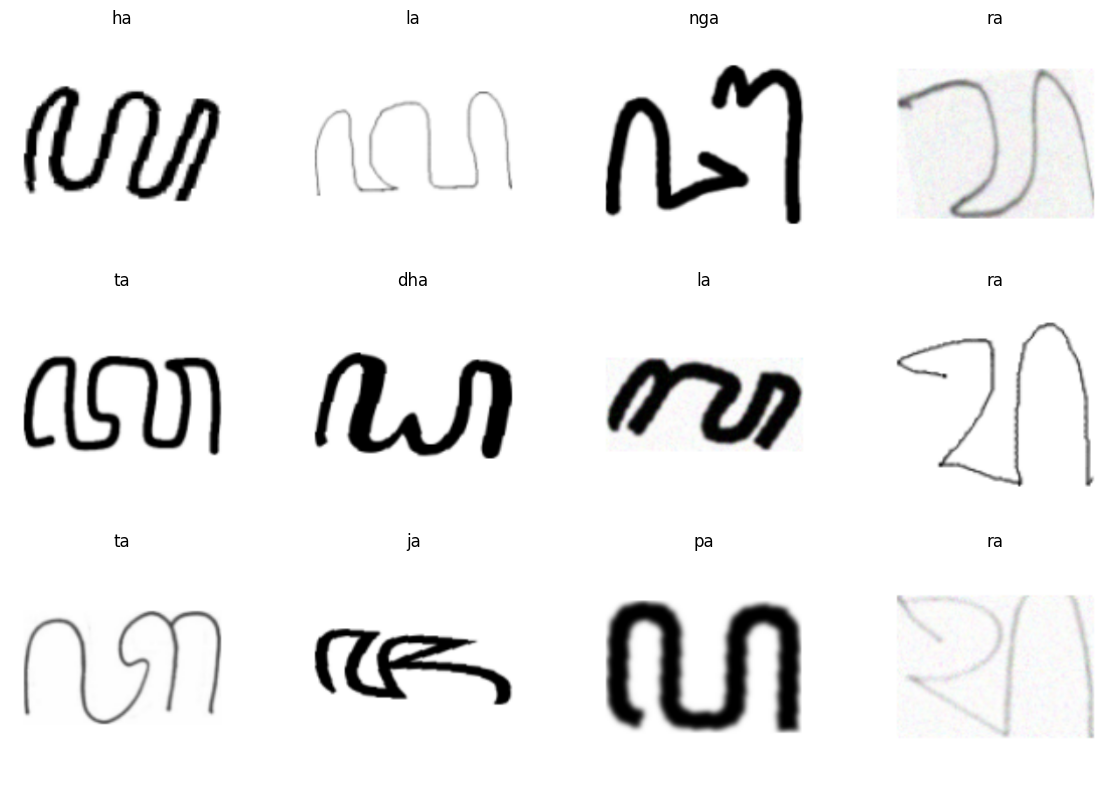

In [ ]:
plt.figure(figsize=(12, 8))

sample_indices = random.sample(range(len(X_train)), min(12, len(X_train)))

for i, idx in enumerate(sample_indices):
    img_raw = tf.io.read_file(X_train[idx])
    img_raw = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
    img_raw = tf.image.resize(img_raw, [IMG_SIZE, IMG_SIZE])
    img_raw = img_raw.numpy().astype("uint8")

    plt.subplot(3, 4, i + 1)
    plt.imshow(img_raw)
    plt.title(class_names[y_train[idx]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# AUGMENTASI DATA

In [ ]:
# Augmentasi ringan agar model lebih kuat terhadap variasi tulisan/gambar.

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.08, 0.08),
], name="data_augmentation")

# MEMBANGUN MODEL RESNET50

In [ ]:
num_classes = len(class_names)

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Tahap awal: layer ResNet50 dibekukan agar training lebih stabil
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, 224, 224, 3)       0         
 ial)                                                            
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_3  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_6 (Dense)             (None, 256)               524544    
                                                                 
 dropout_3 (Dropout)         (None, 256)               0   

# CALLBACK TRAINING

In [ ]:

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

# TRAINING MODEL

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/25
219/219 [==============================] - 723s 3s/step - loss: 2.0344 - accuracy: 0.3694 - val_loss: 1.1735 - val_accuracy: 0.6827
Epoch 2/25
219/219 [==============================] - 662s 3s/step - loss: 1.2525 - accuracy: 0.5953 - val_loss: 0.8504 - val_accuracy: 0.7360
Epoch 3/25
219/219 [==============================] - 689s 3s/step - loss: 0.9901 - accuracy: 0.6729 - val_loss: 0.6555 - val_accuracy: 0.8047
Epoch 4/25
219/219 [==============================] - 659s 3s/step - loss: 0.8325 - accuracy: 0.7221 - val_loss: 0.5998 - val_accuracy: 0.8033
Epoch 5/25
219/219 [==============================] - 695s 3s/step - loss: 0.7463 - accuracy: 0.7469 - val_loss: 0.5375 - val_accuracy: 0.8273
Epoch 6/25
219/219 [==============================] - 744s 3s/step - loss: 0.6630 - accuracy: 0.7781 - val_loss: 0.4593 - val_accuracy: 0.8600
Epoch 7/25
219/219 [==============================] - 696s 3s/step - loss: 0.6356 - accuracy: 0.7831 - val_loss: 0.4129 - val_accuracy: 0.8687

# EVALUASI MODEL PADA DATA TEST

In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_acc)

Test Loss     : 0.22316092252731323
Test Accuracy : 0.9300000071525574


# EVALUASI GRAPH

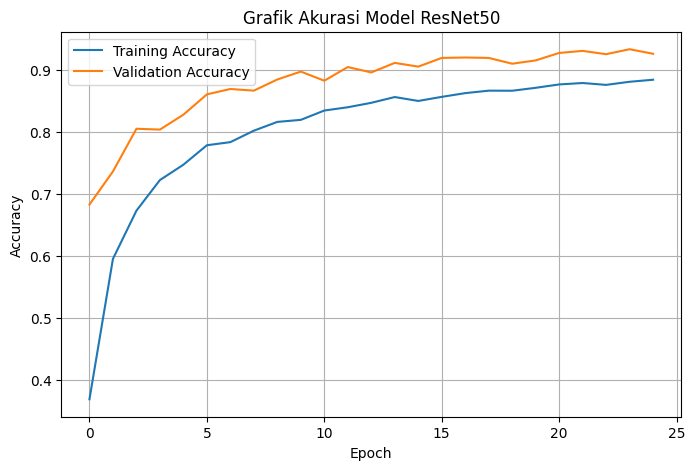

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Grafik Akurasi Model ResNet50")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

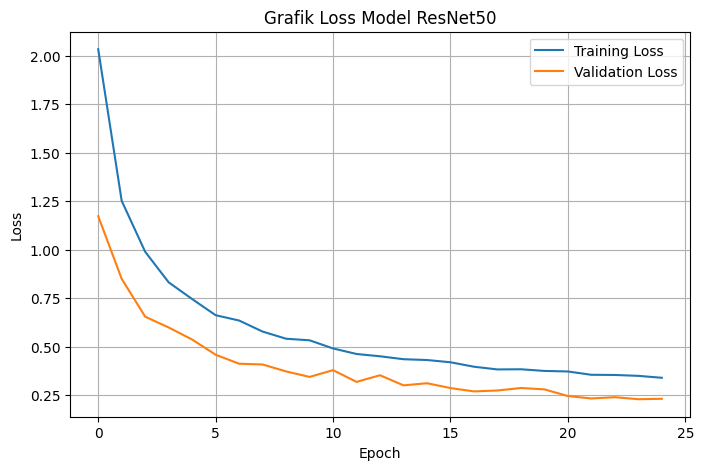

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Grafik Loss Model ResNet50")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# REPORT

In [ ]:
y_true = []
y_pred = []

for images, labels_batch in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels_batch.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

          ba       0.90      0.93      0.92        75
          ca       0.95      0.93      0.94        75
          da       0.91      0.83      0.87        75
         dha       0.93      0.95      0.94        75
          ga       0.93      0.95      0.94        75
          ha       0.74      0.89      0.81        75
          ja       0.97      0.93      0.95        75
          ka       0.99      0.93      0.96        75
          la       0.93      0.69      0.79        75
          ma       0.99      0.99      0.99        75
          na       0.97      0.93      0.95        75
         nga       0.99      1.00      0.99        75
         nya       0.96      0.92      0.94        75
          pa       0.95      0.99      0.97        75
          ra       0.99      0.99      0.99        75
          sa       0.88      0.91      0.89        75
          ta       0.97      0.95      0.96        75
         tha       0.97    

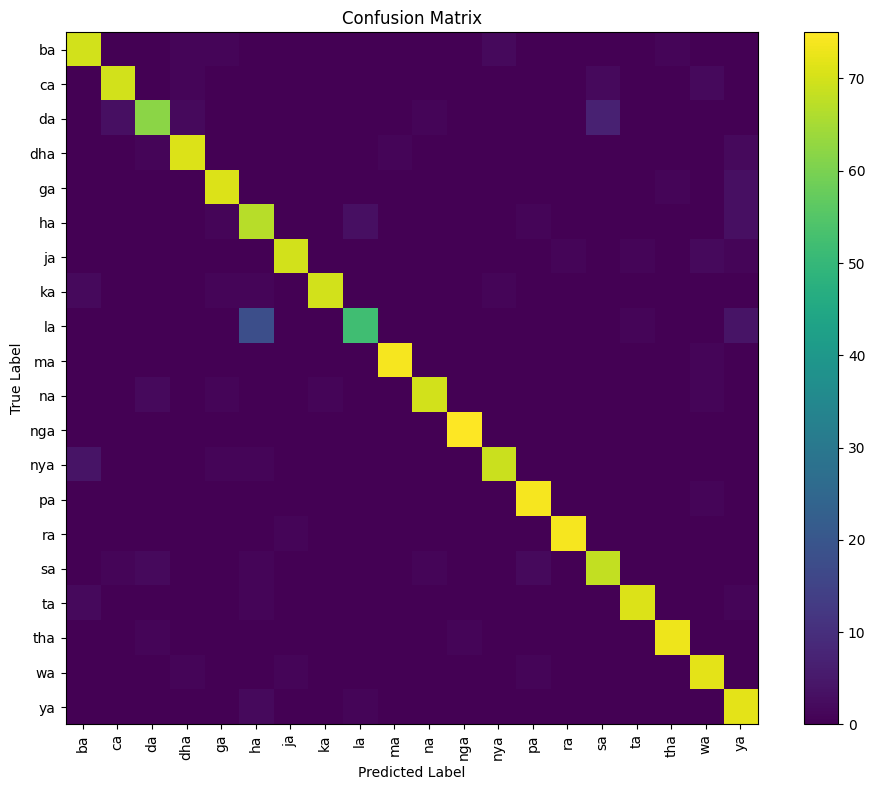

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()

# FINE-TUNING

In [ ]:
# Fine-tuning digunakan jika akurasi pada training masih kurang bagus.
# Fine-tuning membuka sebagian layer terakhir ResNet50.

base_model.trainable = True

# Bekukan sebagian besar layer awal, buka 30 layer terakhir
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
219/219 [==============================] - 1086s 5s/step - loss: 0.1654 - accuracy: 0.9460 - val_loss: 0.1536 - val_accuracy: 0.9580
Epoch 2/10
219/219 [==============================] - 1028s 5s/step - loss: 0.1472 - accuracy: 0.9491 - val_loss: 0.1524 - val_accuracy: 0.9473
Epoch 3/10
219/219 [==============================] - 1037s 5s/step - loss: 0.1349 - accuracy: 0.9557 - val_loss: 0.1318 - val_accuracy: 0.9620
Epoch 4/10
219/219 [==============================] - 1036s 5s/step - loss: 0.1250 - accuracy: 0.9613 - val_loss: 0.1270 - val_accuracy: 0.9687
Epoch 5/10
219/219 [==============================] - 1056s 5s/step - loss: 0.1053 - accuracy: 0.9653 - val_loss: 0.1290 - val_accuracy: 0.9653
Epoch 6/10
219/219 [==============================] - 1041s 5s/step - loss: 0.0975 - accuracy: 0.9680 - val_loss: 0.1221 - val_accuracy: 0.9653
Epoch 7/10
219/219 [==============================] - 1035s 5s/step - loss: 0.0983 - accuracy: 0.9671 - val_loss: 0.1414 - val_accuracy:

# EVALUASI FINE-TUNING

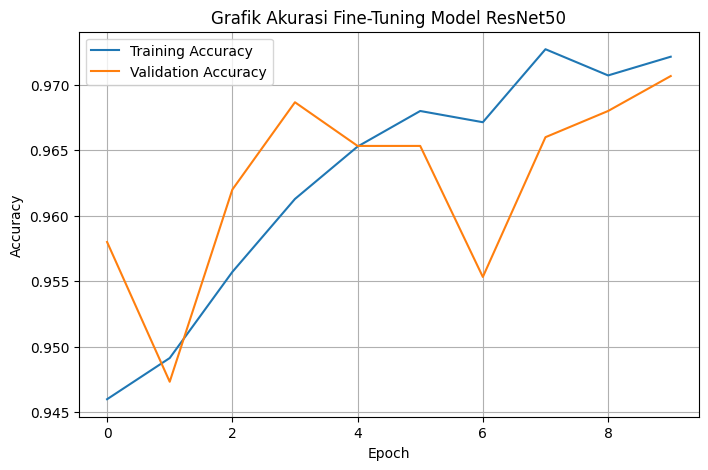

In [51]:
plt.figure(figsize=(8, 5))
plt.plot(fine_tune_history.history["accuracy"], label="Training Accuracy")
plt.plot(fine_tune_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Grafik Akurasi Fine-Tuning Model ResNet50")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

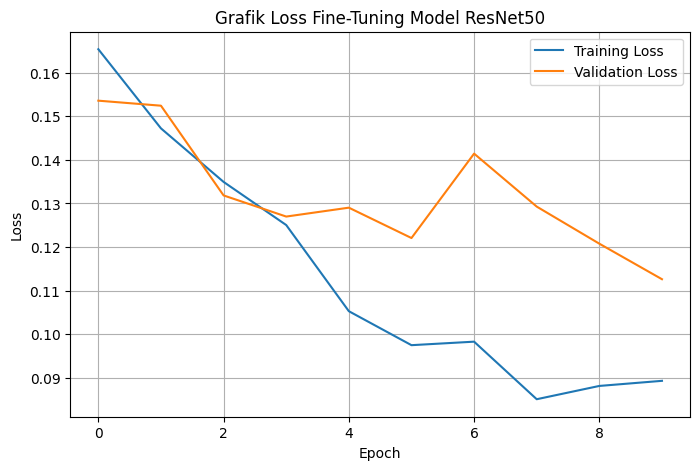

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(fine_tune_history.history["loss"], label="Training Loss")
plt.plot(fine_tune_history.history["val_loss"], label="Validation Loss")
plt.title("Grafik Loss Fine-Tuning Model ResNet50")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# SIMPAN MODEL DAN NAMA KELAS

In [ ]:
# Simpan model dalam format .h5
model.save("resnet50_aksara_jawa.h5")

# Simpan nama kelas dalam .npy
np.save("class_names.npy", np.array(class_names))

print("Model berhasil disimpan sebagai: resnet50_aksara_jawa.h5")
print("Nama kelas berhasil disimpan sebagai: class_names.npy")

c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model berhasil disimpan sebagai: resnet50_aksara_jawa.h5
Nama kelas berhasil disimpan sebagai: class_names.npy


# FUNGSI PREDIKSI GAMBAR

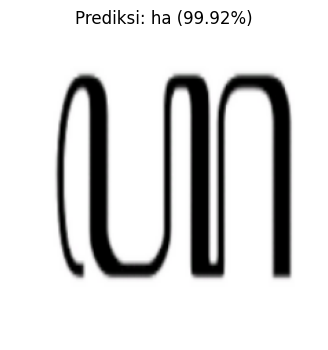

('ha', 0.9991616)

In [ ]:
def predict_aksara(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    img_for_show = img.numpy().astype("uint8")

    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    img = tf.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)[0]
    pred_idx = np.argmax(pred)
    pred_class = class_names[pred_idx]
    confidence = pred[pred_idx]

    plt.figure(figsize=(4, 4))
    plt.imshow(img_for_show)
    plt.title(f"Prediksi: {pred_class} ({confidence:.2%})")
    plt.axis("off")
    plt.show()

    return pred_class, confidence

# Contoh penggunaan:
predict_aksara("Prediksi (ha).png")